In [1]:
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [2]:
import pandas as pd

In [3]:
df = sns.load_dataset('titanic')

In [4]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
#check missing value
df.isnull()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
887,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
889,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [6]:
#check how many null value in column
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

<Axes: xlabel='age', ylabel='Count'>

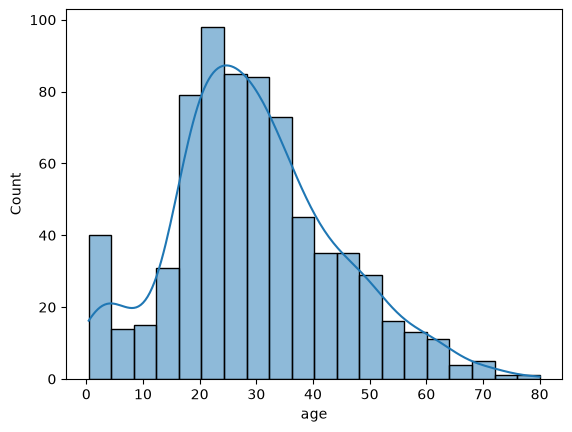

In [15]:
df.dropna(axis=1)
sns.histplot(df['age'] , kde = True)

In [19]:
# first way is = Mean Imputation mtlb ek aur column create krna of age_mean ka udhr age ka mean daaldena instead of deleting whole age so 
# that koi dikkat na ho
df['age_mean'] = df['age'].fillna(df['age'].mean())
df[['age_mean' , 'age']]


,age_mean,age
0,22.000000,22.0
1,38.000000,38.0
2,26.000000,26.0
3,35.000000,35.0
4,35.000000,35.0
...,...,...
886,27.000000,27.0
887,19.000000,19.0
888,29.699118,NaN
889,26.000000,26.0


MEDIAN IMPUTATION --> WORKS BEST FOR OUTLIERS

In [ ]:
#2nd way is Median imputation by doing median  ---> works best if you have outliers
df['age_median'] = df['age'].fillna(df['age'].median())
df[['age_median','age_mean', 'age']]

,age_median,age_mean,age
0,22.0,22.000000,22.0
1,38.0,38.000000,38.0
2,26.0,26.000000,26.0
3,35.0,35.000000,35.0
4,35.0,35.000000,35.0
...,...,...,...
886,27.0,27.000000,27.0
887,19.0,19.000000,19.0
888,28.0,29.699118,NaN
889,26.0,26.000000,26.0


#MODE IMPUTATION --> WHEN THERES SOME CATEGORICAL OR RELATION BETWEEN TWO MISSING VALUE OR SOMETHING  

In [25]:
df[df['embarked'].isnull()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_mean,Age_median,age_median
61,1,1,female,38.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,38.0,38.0,38.0
829,1,1,female,62.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,62.0,62.0,62.0


In [26]:
df['embarked'].unique()

<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

In [33]:
mode_value = df[df['embarked'].notna()]['embarked'].mode()[0]

In [34]:
df['embarked_value'] = df['embarked'].fillna('mode_value')

In [38]:
df[['embarked_value' , 'embarked']]

,embarked_value,embarked
0,S,S
1,C,C
2,S,S
3,S,S
4,S,S
...,...,...
886,S,S
887,S,S
888,S,S
889,C,C


In [43]:
df['embarked_value'].isnull().sum()



np.int64(0)

DATA IMBALANCING--> occurs when you have imbalance data like having 900 yes and 100 no it creates data imbalancing and what are the problems with that is--->that MODEL can get Biased toward yes only so we try that both yes and no have equal shares (dataset becomes equals)
Two way to solve this:-
1) UPSAMPLING
2) DOWN SAMPLING 

In [8]:
import pandas as pd
import numpy as np


#set the random seed for reproductivity  (numpy random number generator startng point)
np.random.seed(123)

class_0_ratio = 0.9
n_smaples = 1000
n_class_0 = int(n_smaples * class_0_ratio)
n_class_1 = n_smaples - n_class0

In [9]:
n_class_0 ,n_class_1  # here dataframe(df) is not build les build in nest step  

(900, 100)

HOW TO CREATE A DATAFRAME WITH IMBALANCED DATSET


In [13]:
class_0 = pd.DataFrame({
    'feature1' : np.random.normal(loc=0, scale = 1, size =n_class_0),
    'feature2' : np.random.normal(loc=0, scale = 1, size = n_class_0),
    'target' : [0]*n_class_0 
     })  #creates a list of 900 zeros.
  #  So feature1 and feature2 are two separate independent columns with different random values
  #  — they just come from the same distribution.
  #Think of it like rolling the same dice twice — same dice, different results.

class_1 = pd.DataFrame({
    'feature1' : np.random.normal(loc=0, scale = 1, size = n_class_1),
    'feature2' : np.random.normal(loc=0, scale = 1, size = n_class_1),
    'target' : [1]*n_class_1  #creates a list of 100 zeros. and here [1] is there not 0 bcz
    #The target is just a label/tag saying:
    #0 = "this sample belongs to class 0"
    #1 = "this sample belongs to class 1" 

}) 
df = pd.concat([class_0,class_1]).reset_index(drop=True)

In [ ]:
#df.isnull().sum()
df['target'].value_counts()
# now we will use UPSAMPLING as to add some artificial data to make both dATA equal mtlb minority ko increase krna hai 

target
0    900
1    100
Name: count, dtype: int64

In [20]:
#upsampling
df_minority = df[df['target']==1]
df_majority = df[df['target']==0]

In [36]:
from sklearn.utils import resample
df_minority_updated = resample(
    df_minority,              # 1. WHAT to resample
    replace=True,             # 2. HOW to pick samples
    n_samples=len(df_majority), # 3. HOW MANY samples you want
    random_state=44           # 4. seed for reproducibility
)

In [34]:
df_updated=pd.concat([df_majority,df_minority_updated])


In [44]:
df_updated['target'].value_counts()


target
0    900
1    900
Name: count, dtype: int64

In [45]:
df

,feature1,feature2,target
0,-1.774224,0.285744,0
1,-1.201377,0.333279,0
2,1.096257,0.531807,0
3,0.861037,-0.354766,0
4,-1.520367,-1.120815,0
...,...,...,...
995,0.677156,-0.907952,1
996,0.963404,-1.818045,1
997,-0.378524,-0.122733,1
998,1.429559,1.794486,1


Downsampling

In [46]:
#downsampling
df_minority = df[df['target']==1]
df_majority = df[df['target']==0]

In [47]:
from sklearn.utils import resample
df_majority_updated = resample(
    df_majority,              # 1. WHAT to resample
    replace=True,             # 2. HOW to pick samples
    n_samples=len(df_minority), # 3. HOW MANY samples you want
    random_state=44           # 4. seed for reproducibility
)

In [48]:
df_updated_fordowsampling = pd.concat([df_majority_updated , df_minority])

In [ ]:
df_updated_fordowsampling.target.value_counts()
#boom downsampling done

target
0    100
1    100
Name: count, dtype: int64

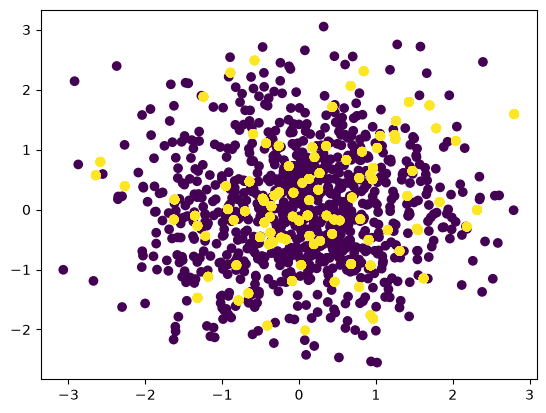

In [53]:
import matplotlib.pyplot as plt

plt.scatter(df_updated['feature1'], df_updated['feature2'], c=df_updated['target'])
plt.show()

### **Smote (better way then up & down Sampling)**

###### *why? bcz in up and down sampling a lot of data got copied like you see in above graph lot of data is on top of eachother* 
###### *so, to solve that we came up with smote technique ---->*
###### *Instead of copying rows, it creates brand new synthetic data points by interpolating*

In [57]:
from sklearn.datasets import make_classification

In [ ]:
x,y = make_classification(n_features=2,n_clusters_per_class= 1 , n_redundant=0, n_samples=1000, weights=[0.90] , random_state=12)

#n_samples=1000-->Total number of rows ... n_features=2-->Number of feature columns ... 
# n_clusters_per_class=1-->How many groups each class forms on a scatter plot

#weights=[0.90]-->The imbalance ratio — most important parameter here!
#weights=[0.90]  # → 90% class 0 (900 rows), 10% class 1 (100 rows)
#weights=[0.50]  # → 50% class 0, 50% class 1 (balanced)

#n_informative-->How many features actually matter for prediction
#n_informative=2  # both features are useful
#n_informative=1  # only 1 feature is useful, other is noise

# make_classification -->What it does
#It's a shortcut to create a fake imbalanced dataset — 
#instead of manually creating class_0, class_1 and concatenating 
#like you did before, this does it all in one line!



In [61]:
import pandas as pd
df1 = pd.DataFrame(x ,columns=['f1' , 'f2'])
df2 = pd.DataFrame(y ,columns=['target'])
df_final = pd.concat([df1,df2] , axis =1)
df_final.head()

,f1,f2,target
0,0.516349,-0.629085,0
1,0.718434,-2.109664,0
2,1.769174,2.899463,1
3,-0.181830,-1.906030,0
4,-0.068734,0.259035,0


In [62]:
df_final['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

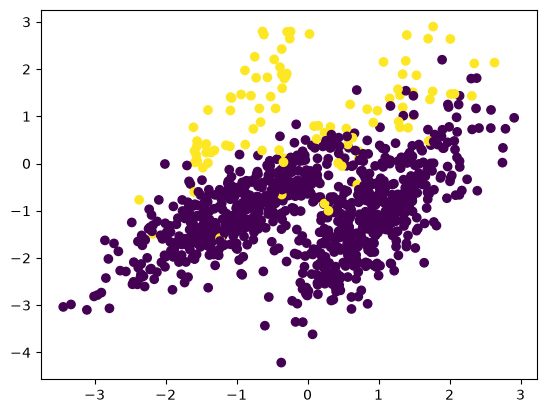

In [64]:
import matplotlib.pyplot as plt
plt.scatter(df_final['f1'], df_final['f2'],c = df_final['target'])

In [70]:
from imblearn.over_sampling import SMOTE


In [79]:
#transforming data
oversample = SMOTE()
x,y = oversample.fit_resample(df_final[['f1','f2']],df_final['target'])
print(type(x))  

<class 'pandas.DataFrame'>


In [ ]:

df_final = pd.concat([df1,df2] , axis =1)

## x and y are now NumPy arrays not DataFrames anymore! so we converted it back
#  but new version of imblearn it prevserses it so no need of doing
#df1 = pd.DataFrame(x ,columns=['f1' , 'f2'])
#df2 = pd.DataFrame(y ,columns=['target'])
#df_final = pd.concat([df1,df2] , axis =1)

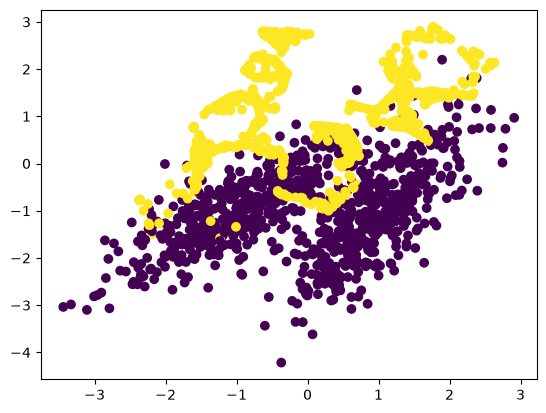

In [81]:
plt.scatter(df_final['f1'], df_final['f2'],c = df_final['target'])

#### Nominal/OHE Encoding

#  *One hot encoding, also known as nominal encoding, is a technique used to represent categorical data as numerical data, which is more suitable for machine learning algorithms. In this technique, each category is represented as a binary vector where each bit corresponds to a unique category. For example, if we have a categorical variable "color" with three possible values (red, green, blue), we can represent it using one hot encoding as follows:*
 ## also you should not use OHE when you have large variance
 ## (like when you have many feature i.e Variance is about how spread out the data is)--> it will cause overfittinh
# Red: [1, 0, 0]
# Green: [0, 1, 0]
# Blue: [0, 0, 1]